# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  

- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.



In [1]:
# importar librerías
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage",usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna())
print(users.isna().mean()*100)

      user_id  first_name  last_name    age   city  reg_date   plan  \
0       False       False      False  False  False     False  False   
1       False       False      False  False  False     False  False   
2       False       False      False  False  False     False  False   
3       False       False      False  False  False     False  False   
4       False       False      False  False  False     False  False   
...       ...         ...        ...    ...    ...       ...    ...   
3995    False       False      False  False  False     False  False   
3996    False       False      False  False  False     False  False   
3997    False       False      False  False  False     False  False   
3998    False       False      False  False  False     False  False   
3999    False       False      False  False  False     False  False   

      churn_date  
0           True  
1           True  
2           True  
3           True  
4           True  
...          ...  
3995        Tr

In [11]:

# cantidad de nulos para usage
usage.isna().sum()

# cantidad datos nulos proporcion
usage.isna().mean()*100


id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---
**Diagnostico**

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- city: 11.725% ,
- churn_date: 88.350% ,
- date: 0.125% ,
- duration: 55.190%,
-  length: 44.740%
  
- Indica qué harías: ¿imputar, eliminar, ignorar?
- city -> Imputar con una categoría como "Desconocido" o dejar como nulos
- churn_date -> significa fecha de cancelación del servicio, podria significar que el usuario no ha cancelado ignorar
- date -> presenta una proporción mínima de nulos; se revisa esos registros y, si son pocos, eliminarlos o corregirlos
- duration ->presenta muchos nulos, pero están relacionados con los registros de tipo text; se recomienda analizar la columna type antes de imputarlos
- length ->presenta muchos nulos, pero corresponden a registros de tipo call; se recomienda analizar la relación con type antes de imputarlos

### 2.2 Detección de valores inválidos y sentinels


🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.



El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:

# explorar columnas numéricas de users
users.select_dtypes(include='number').describe()


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000



- La columna `user_id` es numérica y funciona como identificador único de cada usuario 
- La columna `age`es numérica tiene valores atipicos como -999, reemplazar datos con la mediana

In [13]:
# explorar columnas numéricas de usage
usage.select_dtypes(include='number').describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000



- Las columnas `id` y `user_id`son numéricas,funcionan como identificadores
- Las columnas 'duration' y length son variables numéricas que contienen información sobre el uso del servicio. duration representa la duración de las llamadas y length representa la longitud de los mensajes de texto


In [14]:


# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

users[columnas_user].isna().sum()




city    469
plan      0
dtype: int64

In [15]:
# explorar valores unicos city
users['city'].unique()


array(['Medellín', '?', 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [16]:

# explorar valores unicos plan
users['plan'].unique()


array(['Basico', 'Premium'], dtype=object)

- La columna `city` hay 469 usuarios cuya ciudad no está registrada, valor invalido "?", "nan"
- La columna `plan` todos los usuarios tienen un plan registrado


In [17]:
# explorar columna categórica de usage
usage['type'].isna().sum()

0

In [18]:
# explorar valores unicos usage
usage['type'].unique()

array(['call', 'text'], dtype=object)

- La columna `type` no ytiene  datos nulos


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 


# **Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- Encontré valores inválidos en las columnas `age` y `city`. En age, el valor **-999** es un sentinel porque representa una edad imposible
- city tiene un sentinel "?"
- En `city`, el valor **?** representa un dato desconocido y debe considerarse como faltante
- ¿Qué acción tomarías?
- Reemplazar ambos valores por **NaN** para posteriormente aplicar un tratamiento adecuado de valores faltantes. La columna plan no presenta valores inválidos





### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.


In [19]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])


In [20]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [21]:

# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se identificaron 40 registros con fecha de 2026, los cuales están fuera del periodo de análisis y deben ser revisados para determinar si corresponden a un error en los datos.

In [22]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, todos los registros con fecha corresponden al año 2024, por lo que no se identifican años inválidos o fuera del período de análisis. Sin embargo, existen algunos valores nulos que deben revisarse y tratarse posteriormente 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
- users['reg_date']: se encontraron 40 registros del año 2026, mientras que el período de análisis llega hasta 2024. Estos registros están fuera del rango esperado. Eliminarlos
- usage['date']: Los registros corresponden a 2024 y no presentan años fuera de rango.Tratar los pocos valores nulos.Eliminarlos


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [23]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [24]:
# Reemplazar ? por NA en city
users['city']=users['city'].replace('?',pd.NA)

# Verificar cambios
users['city'].unique()

array(['Medellín', <NA>, 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [25]:
#identificacion de registro de usuarios rag_date 2026
usuarios_2026=users[users['reg_date'].dt.year > 2024]

usuarios_2026=[['user_id','reg_date']]

In [26]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False)

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [27]:
# Verificación MAR en usage (Missing At Random) para duration
usage.loc[usage['duration'].isna(), 'type'].value_counts()

text    22076
Name: type, dtype: int64

In [28]:
# Verificación MAR en usage (Missing At Random) para length
usage.loc[usage['length'].isna(), 'type'].value_counts()

call    17896
Name: type, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length` 

Los valores NaN de duration y length corresponden a faltantes y no aplica para estos registros, duration es nulo únicamente en registros de tipo text, mientras que length es nulo únicamente en registros de tipo call. Esto indica que cada variable no aplica al tipo de actividad correspondiente, por lo que los NaN son esperados y no requieren imputación.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [29]:


# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario

# Renombrar columnas
usage_agg=usage.groupby('user_id').agg(
  cant_mensajes=('is_text','sum'),
  cant_llamadas=('is_call','sum'),
  cant_minutos_llamada=('duration','sum'),
).reset_index()



# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users,usage_agg,on=['user_id'],how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [31]:

# Resumen estadístico de las columnas numéricas
user_profile.select_dtypes(include='number').describe()


,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [32]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---


## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas


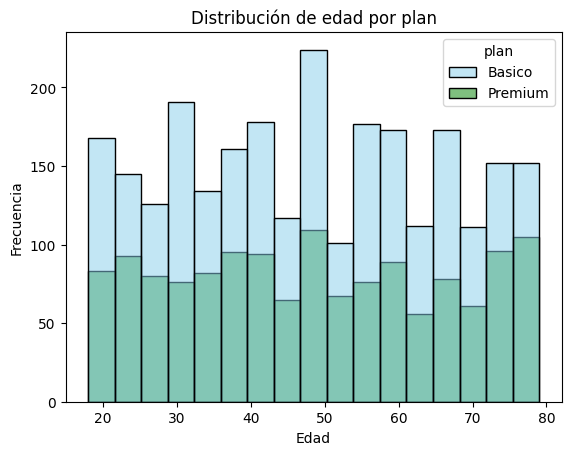

In [33]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile,
            x='age',
            hue='plan',
            palette=['skyblue', 'green']
            )
plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución de edades es bastante amplia en ambos planes, desde aproximadamente 18 hasta 79 años. El plan Básico presenta una mayor frecuencia de usuarios en general, mientras que el plan Premium tiene una distribución más baja pero presente en casi todos los rangos de edad. No se observa una concentración clara de un plan en un rango de edad específico

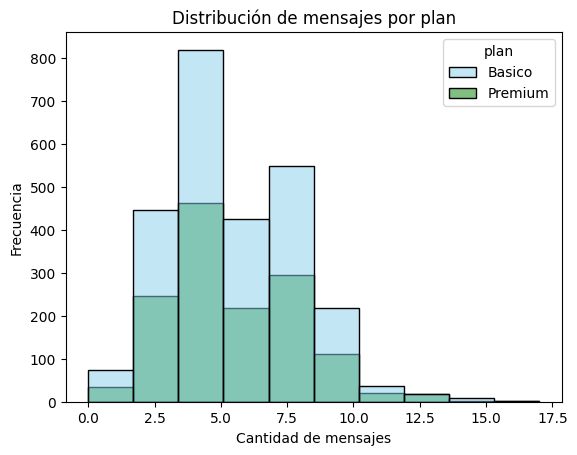

In [34]:

# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=10
)

plt.title('Distribución de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- Ambos planes tienen una distribución similar, con mayor frecuencia en el Básico. La mayoría de los usuarios envía pocos mensajes y solo una minoría supera los 10, mostrando una asimetría hacia la derecha

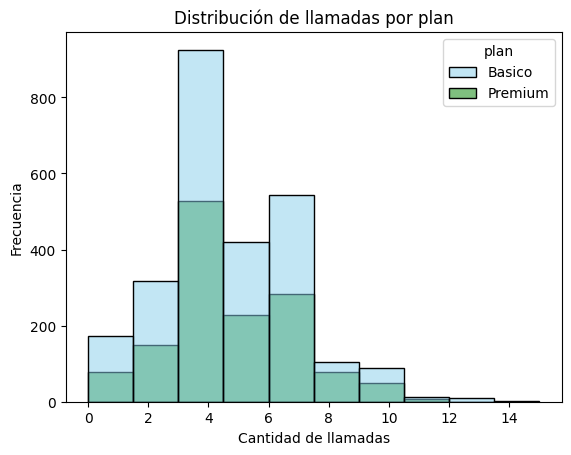

In [35]:

# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=10
)

plt.title('Distribución de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- La mayoría de los usuarios realiza entre 3 y 7 llamadas, independientemente del plan. El consumo disminuye después de 7 llamadas, por lo que no se observa una diferencia marcada entre Básico y Premium en este comportamiento

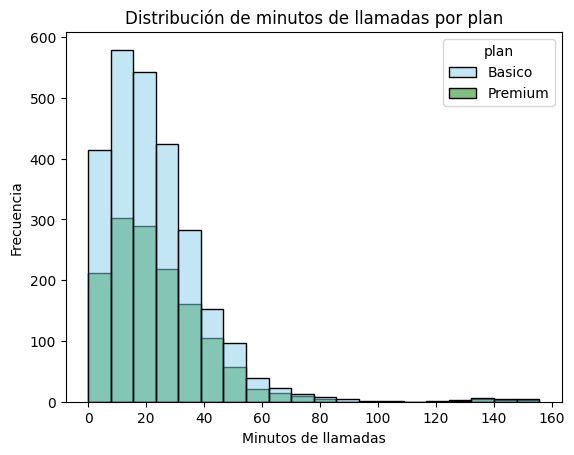

In [36]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Distribución de minutos de llamadas por plan')
plt.xlabel('Minutos de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La mayoría de los usuarios consume entre 10 y 40 minutos de llamadas, con mayor concentración alrededor de 10–20 minutos. La distribución presenta una asimetría hacia la derecha, con pocos usuarios que superan los 60 minutos

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

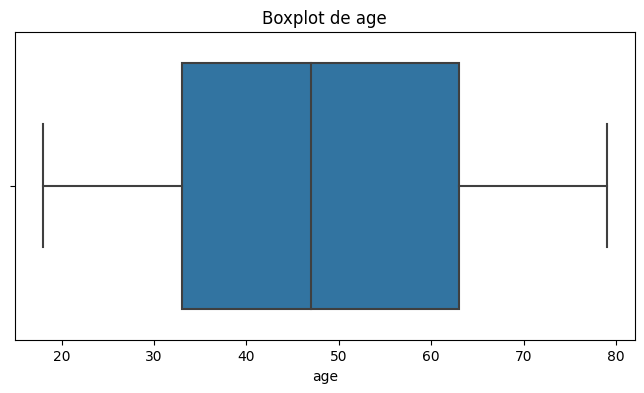

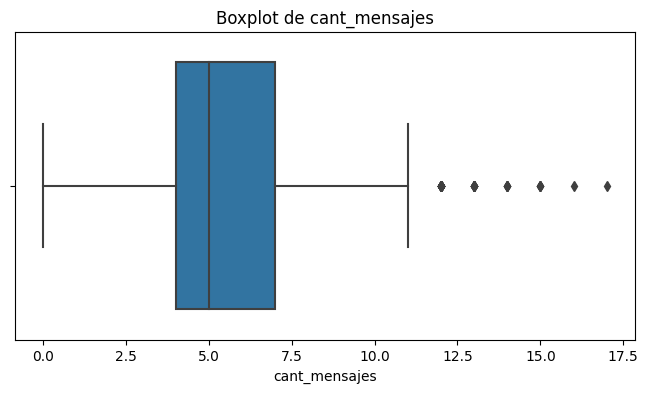

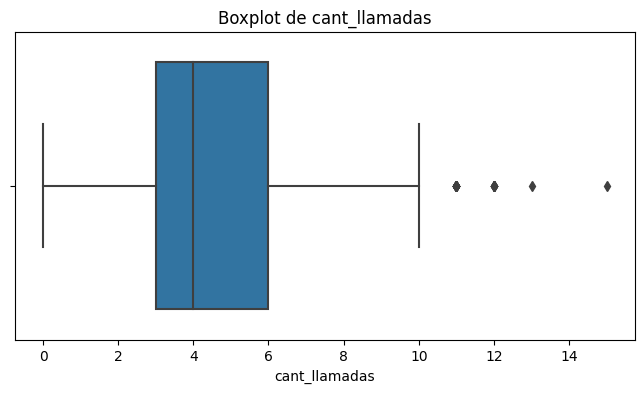

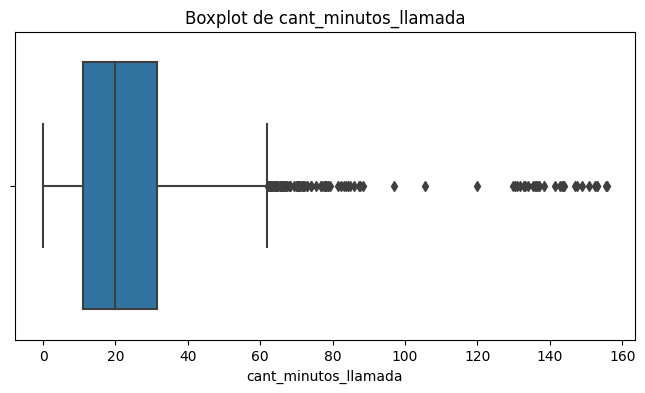

In [37]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age:No presenta outliers; los valores se encuentran dentro de los límites esperados
- cant_mensajes: Presenta algunos outliers en valores altos, aproximadamente entre 12 y 17 mensajes
- cant_llamadas: Presenta algunos outliers en valores altos, aproximadamente entre 11 y 15 llamadas
- cant_minutos_llamada: Se observan varios valores atípicos por encima de 60 minutos, llegando algunos hasta cerca de 150 minutos

In [38]:
# Calcular límites con el método IQR
columnas_limites = ['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3-Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f'\n{col}:')
    print(f'Límite inferior: {limite_inferior:.2f}')
    print(f'Límite superior: {limite_superior:.2f}')


age:
Límite inferior: -12.00
Límite superior: 108.00

cant_mensajes:
Límite inferior: -0.50
Límite superior: 11.50

cant_llamadas:
Límite inferior: -1.50
Límite superior: 10.50

cant_minutos_llamada:
Límite inferior: -19.32
Límite superior: 61.86


In [39]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 

- age: No hay outliers.
- cant_mensajes: Mantener los outliers, porque representan cantidades altas de mensajes que pueden ser parte del comportamiento normal de algunos usuarios.
- cant_llamadas: Mantener los outliers, ya que realizar más llamadas de lo habitual es posible y no necesariamente indica un error.
- cant_minutos_llamada: Mantener los outliers, porque los valores altos pueden representar usuarios con un mayor uso del servicio 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [40]:


# Crear columna grupo_uso
def grupo_uso(llamadas,mensajes):
    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes <10:
        return 'Uso medio'
    else:
        return 'Alto uso'
        
user_profile['grupo_uso']=user_profile.apply(lambda fila: grupo_uso(fila['cant_llamadas'], fila['cant_mensajes']),axis=1)

user_profile[['cant_llamadas', 'cant_mensajes', 'grupo_uso']]




,cant_llamadas,cant_mensajes,grupo_uso
0,3.0,7.0,Uso medio
1,10.0,5.0,Alto uso
2,2.0,5.0,Uso medio
3,3.0,11.0,Alto uso
4,3.0,4.0,Bajo uso
...,...,...,...
3995,3.0,6.0,Uso medio
3996,3.0,4.0,Bajo uso
3997,3.0,5.0,Uso medio
3998,6.0,6.0,Uso medio


In [41]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [42]:
# Crear columna grupo_edad
def grupo_edad(edad):
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'
        
user_profile['grupo_edad']=user_profile.apply(lambda fila: grupo_edad(fila['age']),axis=1)

user_profile[['age', 'grupo_edad']]

,age,grupo_edad
0,38.0,Adulto
1,53.0,Adulto
2,57.0,Adulto
3,69.0,Adulto Mayor
4,63.0,Adulto Mayor
...,...,...
3995,60.0,Adulto Mayor
3996,24.0,Joven
3997,58.0,Adulto
3998,57.0,Adulto


In [43]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor




### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.



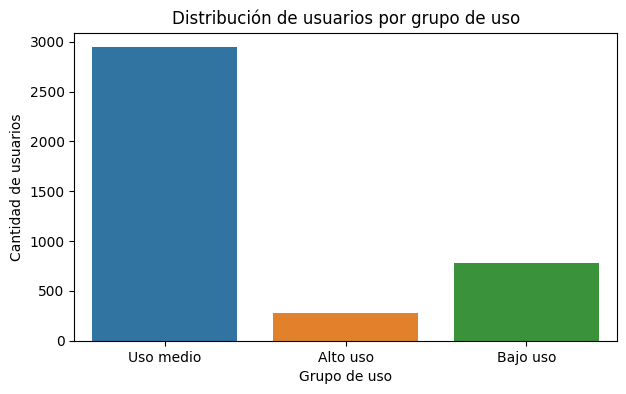

In [44]:


# Visualización de los segmentos por uso
plt.figure(figsize=(7, 4))
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()



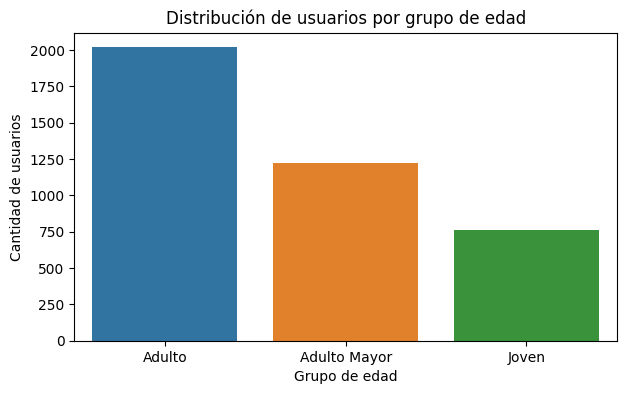

In [45]:

# Visualización de los segmentos por edad
plt.figure(figsize=(7, 4))
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

- En la columna city había 469 valores faltantes, equivalentes al 11.725% de los 4.000 usuarios.
- En churn_date había 3.534 valores faltantes, equivalentes al 88.35%. Estos valores no necesariamente representan un error, ya que pueden corresponder a usuarios que todavía no han cancelado el servicio.
- En age se encontró el valor -999, que es un dato inválido porque representa una edad imposible. Se decidió reemplazarlo por la mediana.
- En city también se encontró el valor "?", utilizado como dato desconocido, por lo que se reemplazó por un valor nulo.
- En reg_date se encontraron 40 registros del año 2026, aunque el período de análisis llega hasta 2024. Estos registros fueron considerados fechas fuera de rango.
- En usage, las columnas duration y length tenían valores nulos, pero se determinó que eran esperados: duration no aplica a registros de mensajes y length no aplica a registros de llamadas. Por esta razón, no era necesario imputarlos.

En general, los problemas de calidad fueron tratados de acuerdo con su naturaleza para evitar alterar información válida


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

Se identificaron dos tipos de segmentación: por nivel de uso y por edad.

*Segmentación por nivel de uso*

*Se crearon tres grupos:*

Bajo uso: clientes con menos de 5 llamadas y menos de 5 mensajes.
Uso medio: clientes con menos de 10 llamadas y menos de 10 mensajes.
Alto uso: clientes que no cumplen las condiciones anteriores.

Según el gráfico, el grupo más grande es Uso medio, con aproximadamente 2.900 usuarios. Le sigue Bajo uso, con alrededor de 780 usuarios, mientras que Alto uso es el grupo más pequeño, con aproximadamente 280 usuarios.

Esto indica que la mayoría de los clientes tienen un consumo moderado, mientras que existe un grupo menor de usuarios con consumo bajo y un grupo reducido de clientes con consumo elevado.

*Segmentación por edad*

*También se identificaron tres grupos:*

Joven: menores de 30 años.
Adulto: entre 30 y 59 años.
Adulto Mayor: 60 años o más.

El segmento Adulto es el más numeroso, con aproximadamente 2.000 usuarios. Después se encuentra Adulto Mayor, con aproximadamente 1.200 usuarios, y finalmente Joven, con alrededor de 800 usuarios.

Por lo tanto, ConnectaTel tiene principalmente clientes adultos y, en cuanto al uso, la mayor parte pertenece al grupo de uso medio.

3. ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

El segmento de Alto uso parece ser uno de los más valiosos porque estos clientes realizan una mayor cantidad de llamadas y envían más mensajes. Aunque es un grupo pequeño, tiene un consumo elevado y, por lo tanto, puede representar una mayor oportunidad de ingresos.

El segmento de Uso medio también es muy importante porque concentra la mayor cantidad de clientes. Es una oportunidad para ConnectaTel porque algunos de estos usuarios podrían aumentar su consumo mediante promociones, beneficios adicionales o planes diseñados para incentivar un mayor uso.

Por edad, el segmento Adulto es especialmente importante porque es el grupo más grande de clientes. Esto significa que cualquier mejora o promoción dirigida a este segmento podría tener un impacto significativo sobre la base total de usuarios

4. ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

Se encontraron outliers principalmente en las variables relacionadas con el uso:

cant_mensajes: algunos usuarios presentan valores altos, aproximadamente entre 12 y 17 mensajes.
cant_llamadas: se encontraron valores elevados, aproximadamente entre 11 y 15 llamadas.
cant_minutos_llamada: existen varios valores superiores a 60 minutos, llegando algunos casos hasta aproximadamente 150 minutos.
age: no presentó outliers.

Estos valores extremos no fueron eliminados, porque pueden representar comportamientos reales de clientes con un nivel de consumo elevado y no necesariamente errores en los datos.

Desde el punto de vista del negocio, estos usuarios pueden ser importantes porque podrían necesitar planes con mayor cantidad de minutos, llamadas o mensajes. Por lo tanto, los outliers pueden convertirse en una oportunidad para identificar clientes de alto consumo y alto valor comercial

5. ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes?

Con base en los segmentos y patrones encontrados, recomiendo lo siguiente:

- Crear un plan para usuarios de alto consumo, con mayor cantidad de minutos, llamadas y mensajes o incluso opciones ilimitadas.
- Mantener una oferta atractiva para el segmento de uso medio, ya que es el grupo más grande. Se podrían ofrecer paquetes que permitan aumentar gradualmente el consumo.
- Crear un plan económico para usuarios de bajo uso, con menos minutos y mensajes y un precio más bajo. Esto permitiría adaptar el costo a las necesidades reales del cliente.
- Desarrollar ofertas diferenciadas por edad. Para los jóvenes se pueden ofrecer planes orientados a un mayor uso de servicios digitales, mientras que para adultos y adultos mayores se pueden priorizar llamadas, facilidad de uso y atención al cliente.
- Fidelizar a los clientes de alto uso, mediante descuentos, beneficios exclusivos o promociones personalizadas, ya que su consumo puede representar un mayor valor para ConnectaTel



### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se encontraron valores faltantes en city (469 usuarios, 11.725%) y en churn_date (88.35%) se consideran esperados cuando el usuario no ha cancelado el servicio
- También se encontraron valores inválidos como -999 en age y "?" en city, además de 40 registros con fechas de registro de 2026, fuera del período de análisis. Estos datos fueron tratados durante la limpieza


🔍 **Segmentos por Edad**
- Adulto es el segmento más grande, con aproximadamente 2,000 usuarios, seguido de Adulto Mayor con cerca de 1,200 y Joven con aproximadamente 800, la mayor parte de los clientes de ConnectaTel se encuentra entre los 30 y 59 años



📊 **Segmentos por Nivel de Uso**
- El grupo de Uso medio es el más numeroso, con aproximadamente 2,900 usuarios. Le siguen Bajo uso con cerca de 780 y Alto uso con aproximadamente 280
- Se encontraron outliers en mensajes, llamadas y minutos de llamadas. Estos valores altos se conservaron porque pueden representar usuarios con un consumo real elevado


➡️ Esto sugiere que ConnectaTel tiene principalmente clientes adultos con un nivel de uso medio. El segmento de alto uso, aunque es más pequeño, puede ser especialmente importante por su mayor consumo


💡 **Recomendaciones**
- Crear planes diferenciados según el nivel de consumo: económicos para usuarios de bajo uso, flexibles para uso medio y con mayores beneficios para usuarios de alto uso.
- Ofrecer promociones y beneficios personalizados para los clientes de alto consumo, y estrategias para incentivar a los usuarios de uso medio a aumentar su consumo

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`